In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint
import itertools
from statsmodels.tsa.stattools import adfuller

In [4]:
df_auto=pd.read_csv("Notebook//sector_prices_automobile.csv")

In [5]:
df_auto.head()

,Date,MARUTI.NS,M&M.NS,BAJAJ-AUTO.NS,HEROMOTOCO.NS,EICHERMOT.NS,TVSMOTOR.NS,ASHOKLEY.NS
0,2022-04-26 00:00:00+05:30,7550.612793,897.569275,3472.404541,2067.380371,2515.233887,670.350708,58.672825
1,2022-04-27 00:00:00+05:30,7437.593750,884.871643,3484.493164,2147.035400,2521.072021,675.367249,57.362968
2,2022-04-28 00:00:00+05:30,7532.850586,881.100525,3420.926514,2161.892822,2544.332520,670.203064,58.085648
3,2022-04-29 00:00:00+05:30,7370.173340,880.336670,3327.382812,2152.746094,2497.242432,644.136597,57.408127
4,2022-05-02 00:00:00+05:30,7290.864258,879.620667,3232.723633,2136.128174,2423.332275,638.431458,57.001625


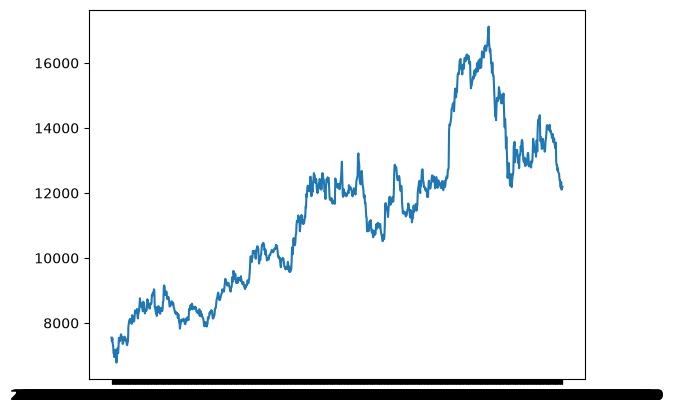

In [6]:
plt.plot(df_auto['Date'],df_auto['MARUTI.NS'])

In [7]:
#We try to normalize so that we can plot all in one graph
normalized = df_auto.drop('Date',axis=1) / df_auto.drop('Date',axis=1).iloc[0] * 100


<Axes: >

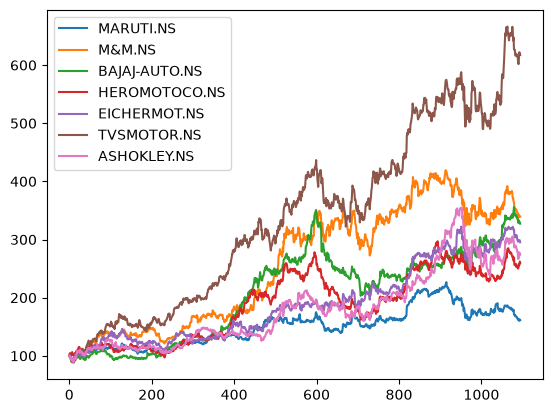

In [8]:
normalized.plot()

In [9]:
corr_mat=df_auto.drop("Date",axis=1).corr()
corr_mat

,MARUTI.NS,M&M.NS,BAJAJ-AUTO.NS,HEROMOTOCO.NS,EICHERMOT.NS,TVSMOTOR.NS,ASHOKLEY.NS
MARUTI.NS,1.000000,0.934855,0.843091,0.917237,0.902909,0.926140,0.875976
M&M.NS,0.934855,1.000000,0.899676,0.915118,0.915086,0.946632,0.888179
BAJAJ-AUTO.NS,0.843091,0.899676,1.000000,0.947554,0.835045,0.916852,0.816449
HEROMOTOCO.NS,0.917237,0.915118,0.947554,1.000000,0.866998,0.932322,0.870179
EICHERMOT.NS,0.902909,0.915086,0.835045,0.866998,1.000000,0.971401,0.961464
TVSMOTOR.NS,0.926140,0.946632,0.916852,0.932322,0.971401,1.000000,0.945249
ASHOKLEY.NS,0.875976,0.888179,0.816449,0.870179,0.961464,0.945249,1.000000


<Axes: >

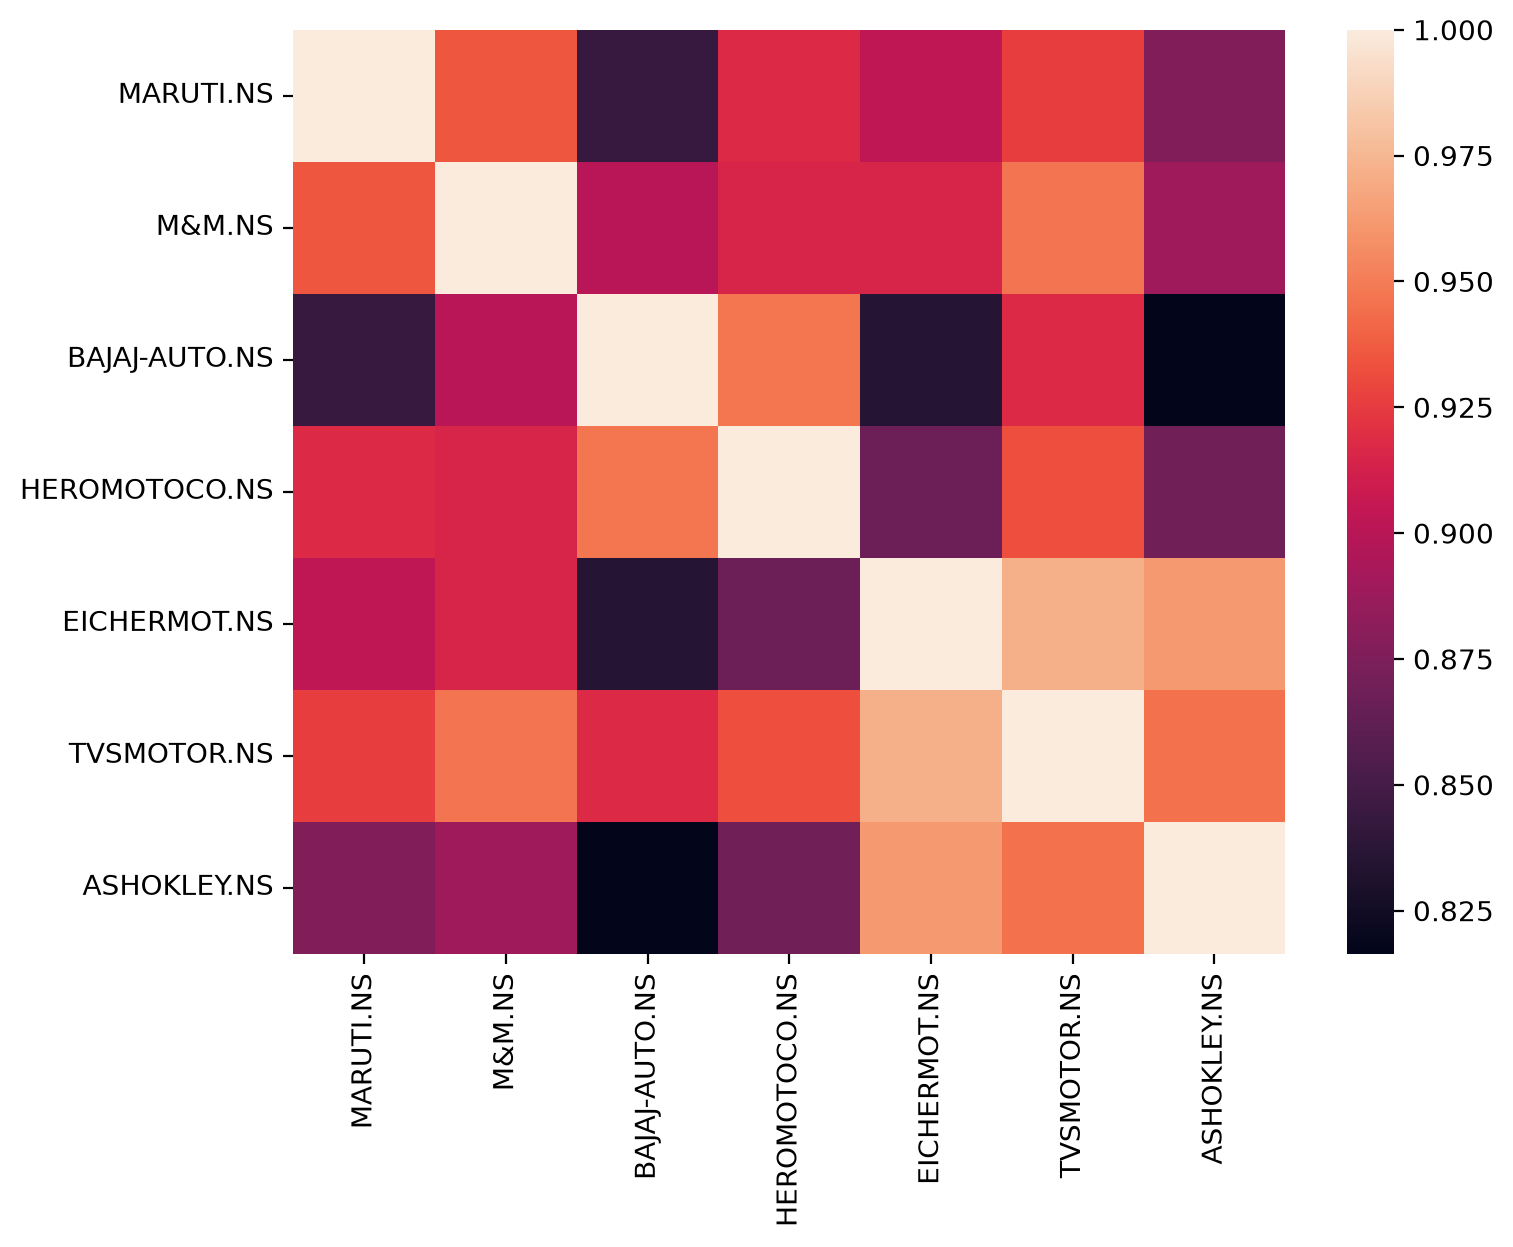

In [10]:
import seaborn as sn
from matplotlib.pyplot import figure
figure(figsize=(8,6),dpi=200)
sn.heatmap(corr_mat)


In [11]:
results=[]
for a,b in itertools.combinations(df_auto.drop('Date',axis=1).columns,2):
    score,p_value,_=coint(df_auto[a],df_auto[b])
    results.append((a,b,p_value))

results_df=pd.DataFrame(results,columns=["Asset A","Asset B","p-value"]).sort_values("p-value")

print(results_df)

          Asset A        Asset B   p-value
19   EICHERMOT.NS    ASHOKLEY.NS  0.037376
18   EICHERMOT.NS    TVSMOTOR.NS  0.106417
0       MARUTI.NS         M&M.NS  0.183080
20    TVSMOTOR.NS    ASHOKLEY.NS  0.334848
11  BAJAJ-AUTO.NS  HEROMOTOCO.NS  0.359316
2       MARUTI.NS  HEROMOTOCO.NS  0.364652
17  HEROMOTOCO.NS    ASHOKLEY.NS  0.466306
7          M&M.NS  HEROMOTOCO.NS  0.521906
10         M&M.NS    ASHOKLEY.NS  0.546349
5       MARUTI.NS    ASHOKLEY.NS  0.578884
15  HEROMOTOCO.NS   EICHERMOT.NS  0.625185
4       MARUTI.NS    TVSMOTOR.NS  0.626289
16  HEROMOTOCO.NS    TVSMOTOR.NS  0.649695
8          M&M.NS   EICHERMOT.NS  0.689757
13  BAJAJ-AUTO.NS    TVSMOTOR.NS  0.696091
6          M&M.NS  BAJAJ-AUTO.NS  0.707423
14  BAJAJ-AUTO.NS    ASHOKLEY.NS  0.737472
1       MARUTI.NS  BAJAJ-AUTO.NS  0.742445
3       MARUTI.NS   EICHERMOT.NS  0.748001
12  BAJAJ-AUTO.NS   EICHERMOT.NS  0.783254
9          M&M.NS    TVSMOTOR.NS  0.892825


In [12]:
import statsmodels.api as sm

# Say your cointegrated pair is A and B
X = sm.add_constant(df_auto['EICHERMOT.NS'])  # independent variable
y = df_auto['ASHOKLEY.NS']                    # dependent variable

model = sm.OLS(y, X).fit()
hedge_ratio = model.params['EICHERMOT.NS']
print(f"Hedge ratio (beta): {hedge_ratio:.4f}")

#Here i have used a static hedge ratio so the mean reversion is not that great we want to make it dynamic

Hedge ratio (beta): 0.0224


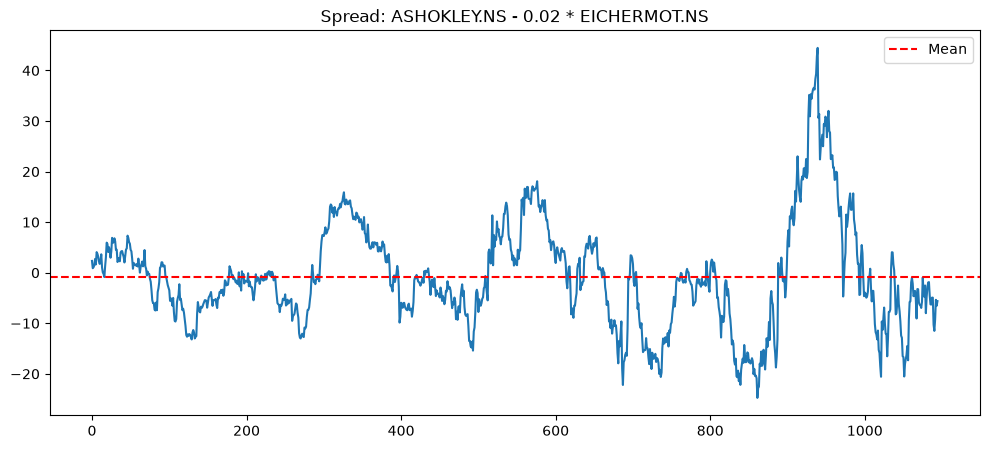

In [13]:
spread = df_auto['ASHOKLEY.NS'] - hedge_ratio * df_auto['EICHERMOT.NS']

import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(spread)
plt.axhline(spread.mean(), color='red', linestyle='--', label='Mean')
plt.title(f"Spread: {'ASHOKLEY.NS'} - {hedge_ratio:.2f} * {'EICHERMOT.NS'}")
plt.legend()
plt.show()

#What you should see really here is the price should alway ossilate around the mean and there no constant one way moment

In [ ]:
adf_test=adfuller(spread)
print("ADF Statistic:", adf_test[0])
print("p-value:", adf_test[1])
#If p < 0.05, the series is likely stationary.

ADF Statistic: -3.5142780557359634
p-value: 0.007627886252492461


C:\Users\shxpat\AppData\Local\Temp\ipykernel_21484\2474465534.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_test=adfuller(spread)


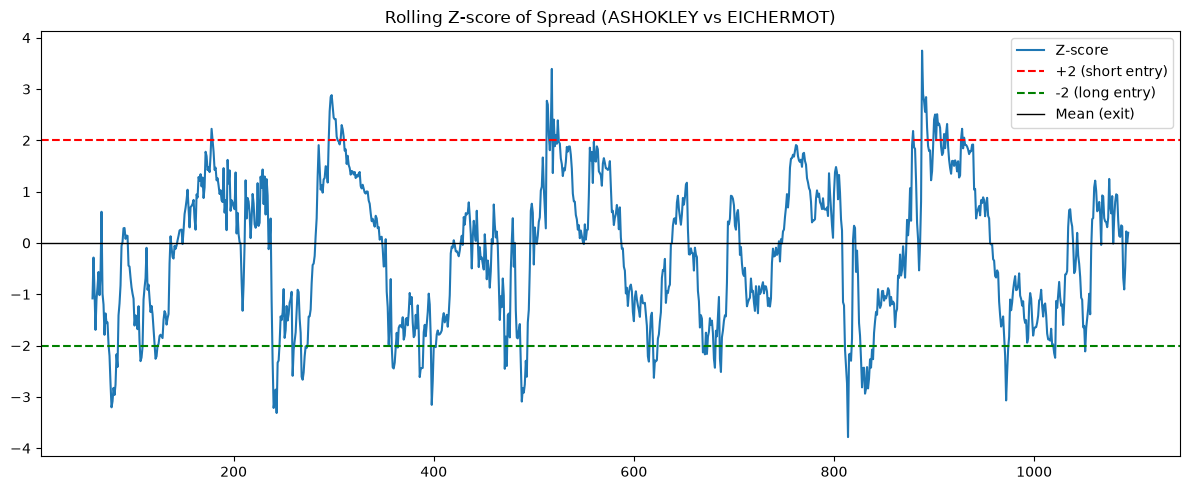

In [20]:
# Static spread (already computed) — ASHOKLEY - 0.02 * EICHERMOT
spread = df_auto['ASHOKLEY.NS'] - hedge_ratio * df_auto['EICHERMOT.NS']

# Rolling window for mean/std — separate from the hedge ratio, just for z-scoring
roll_window = 60

rolling_mean = spread.rolling(roll_window).mean()
rolling_std = spread.rolling(roll_window).std()

z_score = (spread - rolling_mean) / rolling_std

# Plot the z-score with entry/exit reference lines
plt.figure(figsize=(12, 5))
plt.plot(z_score, label="Z-score")
plt.axhline(2, color='red', linestyle='--', label='+2 (short entry)')
plt.axhline(-2, color='green', linestyle='--', label='-2 (long entry)')
plt.axhline(0, color='black', linestyle='-', linewidth=1, label='Mean (exit)')
plt.title("Rolling Z-score of Spread (ASHOKLEY vs EICHERMOT)")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
import numpy as np
import pandas as pd

signal = pd.Series(np.nan, index=z_score.index)

signal[z_score > 2] = -1    # short the spread
signal[z_score < -2] = 1    # long the spread
signal[z_score.abs() < 0.5] = 0  # exit signal

# Forward-fill: hold the last signal until a new one appears
positions = signal.ffill().fillna(0)  # fillna(0) handles the very start, before any signal

In [24]:
positions.value_counts()

 0.0    645
 1.0    305
-1.0    145
Name: count, dtype: int64